https://drive.google.com/drive/folders/1WYxnu8Hrv7JLc5HBgZmxigMvJRNTKmdh?usp=drive_link

https://drive.google.com/drive/folders/1w8_nWdz2FfEdXHKmn4ifxuZn6ErX2HKb?usp=drive_link masks

https://drive.google.com/drive/folders/12Mgtd9FHR0R7rqJ1D3l9ONce0AlvfK4V?usp=sharing images

Multi‑class (akciğer + pnömotoraks):
- Maskeler tek kanal, integer değerli.
- Piksel değerleri:
- 0 → arka plan (işaretlenmesine gerek yok default koyuyor)
- 1 → akciğer (sadece sağlam alan)
- 2 → pnömotoraks (sadece hasta alan)
- Annotator hem akciğer sınırını hem pnömotoraksı işaretleyecek.


📝 Annotator(segmentasyon yapan kişi) için yönerge 
- Görselleri images/ klasörüne koy. (Hepsi Dicom formatında olmalı.  PNG veya JPEG olmamalı)

- Her görsel için aynı isimle bir maske dosyası oluştur ve masks/ klasörüne kaydet.

- Maskeler tek kanal olacak. (RGB değil yani.)

- Eğer sadece pnömotoraks işaretlenecekse: pnömotoraks alanlarını beyaz (255), diğer her şeyi siyah (0) yap. (Bu yol kullanılmayacak çünkü yüzdelik hesap yapılamaz)

- Eğer akciğer + pnömotoraks işaretlenecekse: arka plan 0, sağlıklı akciğer 1, pnömotoraks 2 olacak şekilde kaydet. Arka planı işaretlemene gerek yok sadece "sağlıklı akciğer kısmı (bütün akciğer - pnömotoraks)" = 1, "pnömotoraks" = 2 olsun. Renk olarak işaretlenmeyecek sadece ID seçilip öyle işaretlenecek ve bu ID'ler burada yazılanlara uygun olmalı. Dicom Seg olarak kaydedilecek segmentasyon sonrası.

- İlk olarak 1 numaralı kodu çalıştır. Bu hücre images/ klasöründeki bütün dicom'ları 256x256 boyutuna ayarlar ve resized_images/ klasörüne kaydeder.

- Kontrol etmek için 2 ve 3 numaralı hücreleri çalıştır.

- Modelin çalışması için dosya yolu 4 numaralı hücredeki gibi olmalı.

- Model ise 5 numaralı büyük kod bloğunda. Emin olduktan sonra çlaıştırlır.

- Eğitim sonrası 6. hücre test etmek içindir. Model ağırlıkları yüklenir ve test paramtreleri incelenir. (save_path = "./smp_unet_best.pth")

# 1. random sized dicom -> 256x256 dicom

In [5]:
import os
import pydicom
import numpy as np
from PIL import Image
from pathlib import Path

# Klasör yolları
dataset_path = Path('./dataset')
images_path = dataset_path / 'images'
resized_path = dataset_path / 'resized_images'

# resized_images klasörünü oluştur
resized_path.mkdir(exist_ok=True)

# images klasöründeki tüm dosyaları işle
for filename in os.listdir(images_path):
    input_file = images_path / filename
    
    try:
        # DICOM dosyasını oku
        dicom_file = pydicom.dcmread(input_file)
        
        # Pixel data'yı numpy array'e çevir
        image_array = dicom_file.pixel_array
        input_shape = image_array.shape
        
        # Eğer 3 channel varsa, gri tonlamaya çevir (DICOM genellikle gri)
        if len(image_array.shape) == 3:
            image_array = np.mean(image_array, axis=2).astype(np.uint8)
        else:
            # Değerleri 0-255 aralığına normalize et
            image_array = ((image_array - image_array.min()) / (image_array.max() - image_array.min()) * 255).astype(np.uint8)
        
        # PIL Image'e dönüştür
        pil_image = Image.fromarray(image_array)
        
        # 256x256'ya resize et
        resized_image = pil_image.resize((256, 256), Image.Resampling.LANCZOS)
        
        # Resized görüntüyü numpy array'e geri çevir
        resized_array = np.array(resized_image)
        output_shape = resized_array.shape
        
        # DICOM dosyasını güncelle
        resized_bytes = resized_array.tobytes()
        dicom_file.PixelData = resized_bytes
        dicom_file.Rows = 256
        dicom_file.Columns = 256
        dicom_file.BitsAllocated = 8
        dicom_file.BitsStored = 8
        dicom_file.HighBit = 7
        
        # Yeni DICOM dosyasını kaydet
        output_file = resized_path / filename
        dicom_file.save_as(output_file)
        
        print(f"✓ file name : {filename} | Input: {input_shape} -> Output: {output_shape}")
    except Exception as e:
        print(f"✗ {filename} - Error: {e}")

print(f"\nTüm dosyalar {resized_path} klasörüne kaydedildi!")

✓ file name : 15642137 | Input: (2320, 2828) -> Output: (256, 256)

Tüm dosyalar dataset\resized_images klasörüne kaydedildi!


# 2. Random sized dicom'ları açmak için kod(kontrol)

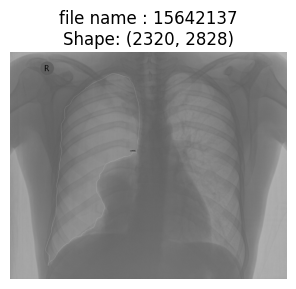

In [6]:
import matplotlib.pyplot as plt

# resized_images klasöründeki dosyaları göster
images_file = list(images_path.glob('*'))
num_files = min(len(images_file), 5)  # İlk 5 dosyayı göster

fig, axes = plt.subplots(1, num_files, figsize=(15, 3))
if num_files == 1:
    axes = [axes]

for idx, file_path in enumerate(images_file[:num_files]):
    try:
        dicom = pydicom.dcmread(file_path)
        img_array = dicom.pixel_array
        
        axes[idx].imshow(img_array, cmap='gray')
        axes[idx].set_title(f"file name : {file_path.name}\nShape: {img_array.shape}")
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Error: {e}", ha='center', va='center')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

# dönüşüm öncesi

# 3. resized (256x256) dicom'ları açmak için kod(kontrol)

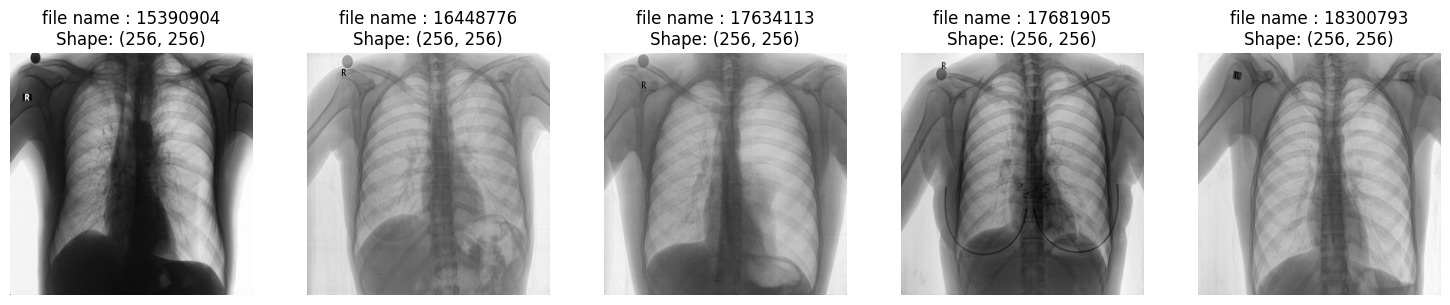

In [12]:
import matplotlib.pyplot as plt
import os
import pydicom
import numpy as np
from PIL import Image
from pathlib import Path


# Klasör yolları
dataset_path = Path('./dataset')
images_path = dataset_path / 'images'
resized_path = dataset_path / 'resized_images'

# resized_images klasöründeki dosyaları göster
resized_files = list(resized_path.glob('*'))
num_files = min(len(resized_files), 5)  # İlk 5 dosyayı göster

fig, axes = plt.subplots(1, num_files, figsize=(15, 3))
if num_files == 1:
    axes = [axes]

for idx, file_path in enumerate(resized_files[:num_files]):
    try:
        dicom = pydicom.dcmread(file_path)
        img_array = dicom.pixel_array
        
        axes[idx].imshow(img_array, cmap='gray')
        axes[idx].set_title(f"file name : {file_path.name}\nShape: {img_array.shape}")
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Error: {e}", ha='center', va='center')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

# dönüşüm sonrası

In [11]:
import nibabel as nib, numpy as np, os

images, masks = [], []
for f in os.listdir("dataset/masks"):
    path = os.path.join("dataset/masks", f)
    data = nib.load(path).get_fdata()
    uniq = np.unique(data)
    if np.all(np.isin(uniq, [0,1,2])):
        masks.append(f)
    else:
        images.append(f)

print("Images:", len(images))
print("Masks:", len(masks))

Images: 0
Masks: 230


In [1]:
import os
import shutil

images_dir = "dataset/images"
masks_dir = "dataset/masks"
resized_dir = "dataset/resized_images"

os.makedirs(resized_dir, exist_ok=True)

# Mask dosyalarının isimlerini set olarak al
mask_names = {os.path.splitext(os.path.splitext(f)[0])[0] for f in os.listdir(masks_dir)}

count = 0
for f in os.listdir(images_dir):
    # Uzantısız dosya adı
    base = os.path.splitext(os.path.splitext(f)[0])[0]
    if base in mask_names:
        src = os.path.join(images_dir, f)
        dst = os.path.join(resized_dir, f)
        shutil.copy(src, dst)
        count += 1

print(f"Eşleşen {count} görüntü kopyalandı → {resized_dir}")

Eşleşen 183 görüntü kopyalandı → dataset/resized_images


# 4. Olması gereken dosya yapısı

In [ ]:
"""
ENG401/
    ENG401.ipynb
    dataset/
        images/
            case1.dicom(shpaed random)
            case2.dicom(shaped random)
            ...
        masks/
            case1   # case1 görüntüsünün maskesi
            case2   # case2 görüntüsünün maskesi
            ...
        resized_images/
            case1.dicom(shaped 256x256)
            case2.dicom(shaped 256x256)
            ...



- images/ klasöründe X ray görüntüleri (DICOM’dan çevrilmiş).
- masks/ klasöründe aynı isimli dosyalar, ama bunlar piksel bazlı etiketler.
- resized_images/ klasöründe X ray görüntüleri (Herhangi bir shape'den 256x256 olarak ayarlanmış halleri.)

"""

# 5. 2D Model (lokasyon bulan + yüzde kaçı hasta) -- kullanılmayacak

In [ ]:
# -*- coding: utf-8 -*-
# Jupyter-ready: single block, with comments explaining each step.
# What’s new vs your code:
# - Robust DICOM read with optional windowing and PixelSpacing extraction
# - 2.5D option (stack K neighboring slices as channels) without 3D CNN
# - Multi-class masks (background, lung, pneumothorax) or binary masks
# - Pneumothorax percentage computation using lung masks (or hemithorax proxy)
# - Clean small components to reduce noise, per-side (left/right) percentages
# - AMP (mixed precision), gradient clipping, and proper encoder freeze/unfreeze

import os, cv2, random, math, pydicom, numpy as np
import pandas as pd
import torch, torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, jaccard_score, confusion_matrix


# -------------------------------
# DICOM helpers
# -------------------------------

def read_dicom_to_rgb_uint8(path, window=None, out_range=(0,255)):
    """
    DICOM -> HxWx3 uint8 RGB for ImageNet-pretrained 2D encoders.
    window=(center, width) for CT; for X-ray often None (min-max rescale).
    """
    ds = pydicom.dcmread(path)
    img = ds.pixel_array.astype(np.float32)

    # Rescale slope/intercept if present
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept

    # Optional windowing (mostly CT; X-ray usually direct min-max)
    if window is not None:
        c, w = window
        img = np.clip(img, c - w/2, c + w/2)

    # Min-max scale to uint8
    mi, ma = img.min(), img.max()
    if ma == mi:
        img8 = np.zeros_like(img, dtype=np.uint8)
    else:
        img8 = ((img - mi) / (ma - mi) * (out_range[1] - out_range[0]) + out_range[0]).astype(np.uint8)

    # Replicate to 3 channels (RGB) for pretrained 2D encoders
    img3 = np.repeat(img8[..., None], 3, axis=-1)
    return img3, ds

def get_pixel_spacing_mm(ds):
    """
    Extract PixelSpacing from DICOM for physical area (mm^2).
    Returns (sx, sy) or (1.0, 1.0) if missing.
    """
    ps = getattr(ds, "PixelSpacing", None)
    if ps is None or len(ps) < 2:
        # fallback if spacing missing
        return 1.0, 1.0
    try:
        return float(ps[1]), float(ps[0])  # sx (cols), sy (rows)
    except Exception:
        return 1.0, 1.0

# -------------------------------
# CFG
# -------------------------------

global_mask_mode = "multi"
binary = False
# multiclass için default params

class CFG:
    data_root      = "./dataset"   # images/ and masks/ (same filenames)
    img_size       = 256
    batch_size     = 8
    num_workers    = 2
    encoder        = "resnet34"           # strong and fast baseline
    encoder_weights= "imagenet"
    freeze_epochs  = 3                    # decoder-only warmup
    max_epochs     = 12
    lr_decoder     = 1e-3
    lr_full        = 1e-4
    device         = "cuda" if torch.cuda.is_available() else "cpu"
    save_path      = "./smp_unet_best.pth"
    # New:
    use_amp        = True                 # mixed precision
    grad_clip      = 1.0                  # clip to stabilize
    mask_mode      = global_mask_mode            # "binary" -> 1 class (ptx), "multiclass" -> 3 classes (bg, lung, ptx)
    # For multiclass: we expect masks encoded as 0=bg,1=lung,2=ptx (single-channel int image). We one-hot them.
    # For binary: masks are single-channel 0/1 (ptx)
    use_25d        = False                # 2.5D input: stack K neighboring slices as channels
    k_slices       = 5                    # odd number (e.g., 3/5/7)
    # Pneumothorax percentage computation
    min_ptx_area_px= 80                   # remove tiny components
    # If lung mask absent and mask_mode==binary, use proxy hemithorax split to estimate percentages
    use_hemithorax_proxy = True

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print("Device:", CFG.device)

# -------------------------------
# Dataset (supports DICOM, PNG/JPG)
# - Binary mode: expects masks as single-channel 0/1 (ptx)
# - Multiclass mode: expects masks encoded with integer labels: 0=bg,1=lung,2=ptx
# - 2.5D: stack K neighboring slices as channels, still goes to a 2D network (no 3D CNN)
# -------------------------------

def one_hot_encode_mask(mask_int, num_classes):
    """
    mask_int: HxW integer labels [0..num_classes-1]
    returns: CxHxW float32 one-hot
    """
    h, w = mask_int.shape
    out = np.zeros((num_classes, h, w), dtype=np.float32)
    for c in range(num_classes):
        out[c] = (mask_int == c).astype(np.float32)
    return out

class SegDataset(Dataset):
    def __init__(self, images_dir, masks_dir, file_list=None, transform=None,
                 as_rgb=False, mask_mode=global_mask_mode, use_25d=False, k_slices=5):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.files = file_list if file_list is not None else sorted(os.listdir(images_dir))
        self.transform = transform
        self.as_rgb = as_rgb          # True: image already RGB file; False: grayscale → expand to 3ch
        self.mask_mode = mask_mode    # "binary" or "multiclass"
        self.use_25d = use_25d
        self.k_slices = k_slices      # odd number; center slice gets label

    def __len__(self):
        return len(self.files)

    def _load_image(self, img_path):
        # Returns (img_rgb_uint8, spacing_mm)
        if img_path.lower():
            img, ds = read_dicom_to_rgb_uint8(img_path, window=None)
            sx, sy = get_pixel_spacing_mm(ds)
            return img, (sx, sy)
        else:
            if self.as_rgb:
                img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
                if img_bgr is None: raise FileNotFoundError(f"Image not found: {img_path}")
                img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            else:
                gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if gray is None: raise FileNotFoundError(f"Image not found: {img_path}")
                img = np.repeat(gray[..., None], 3, axis=-1)
            return img, (1.0, 1.0)  # spacing unknown for non-DICOM

    def _load_mask(self, mask_path):
        """
        Load segmentation mask from DICOM or PNG/JPEG/TIFF.
        - Binary: single-channel 0/1
        - Multiclass: single-channel ints {0:bg,1:lung,2:ptx}
        """
        m = None

        # Önce DICOM olarak dene
        try:
            ds = pydicom.dcmread(mask_path)
            m = ds.pixel_array.astype(np.int32)
        except Exception:
            # Eğer DICOM değilse, klasik görsel olarak dene
            m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if m is None:
                raise FileNotFoundError(f"Mask not found or unreadable: {mask_path}")

        # --- Binary / Multiclass ayrımı ---
        if self.mask_mode == "binary":
            return (m > 127).astype(np.float32)  # HxW
        else:
            m[m == 255] = 0
            valid_classes = [0, 1, 2]
            m[~np.isin(m, valid_classes)] = 0
            return m.astype(np.int32)  # HxW ints


    def __getitem__(self, idx):
        fname = self.files[idx]

        # 2.5D mode: stack K neighboring slices as channels (still RGB expected by transforms; we'll override)
        if self.use_25d:
            # Expect numbered files enabling neighbor retrieval (e.g., name_i.png); simple fallback: just load same file K times
            # You can customize this to your filename convention. Here we just replicate the same image K times for demo.
            img_path = os.path.join(self.images_dir, fname)
            imgs, spacings = [], []
            for _ in range(self.k_slices):
                img, sp = self._load_image(img_path)
                imgs.append(img[..., 0])  # take grayscale channel to form multi-channel stack
                spacings.append(sp)
            # Stack K slices as channels (HxWxK), then expand to 3 via tiling if your transforms expect 3ch
            stack = np.stack(imgs, axis=-1)  # HxWxK
            # Convert to 3 channels by linear projection: for SMP ImageNet encoders we need 3ch,
            # simple approach: take [K→3] using first 3 channels or averaged projections.
            if stack.shape[-1] >= 3:
                img = stack[..., :3]  # HxWx3
            else:
                # Tile to 3
                img = np.tile(stack, (1,1,math.ceil(3/stack.shape[-1])))[:, :, :3]
            spacing = spacings[0]
        else:
            img_path = os.path.join(self.images_dir, fname)
            img, spacing = self._load_image(img_path)

        mask_path = os.path.join(self.masks_dir, fname)
        mask_raw = self._load_mask(mask_path)

        # Albumentations expects image uint8 (HxWxC) and mask HxW (or CxHxW after ToTensorV2)
        if self.transform:
            if self.mask_mode == "binary":
                aug = self.transform(image=img, mask=mask_raw)
                img_t = aug["image"]                      # Tensor [3,H,W]
                mask_t = aug["mask"].unsqueeze(0).float() # [1,H,W]
            else:
                # For multiclass we pass single-channel ints through transforms, then one-hot
                aug = self.transform(image=img, mask=mask_raw)
                img_t = aug["image"]
                mask_int = aug["mask"].long()             # [H,W] ints
                mask_oh = one_hot_encode_mask(mask_int.cpu().numpy(), num_classes=3) # [C,H,W]
                mask_t = torch.from_numpy(mask_oh).float()
        else:
            # Fallback no-transform
            img_t = torch.from_numpy(img.transpose(2,0,1)).float() / 255.0
            if self.mask_mode == "binary":
                mask_t = torch.from_numpy(mask_raw[None]).float()
            else:
                mask_oh = one_hot_encode_mask(mask_raw, num_classes=3)
                mask_t = torch.from_numpy(mask_oh).float()

        return img_t, mask_t, spacing, fname

# -------------------------------
# Data split and transforms
# -------------------------------

images_dir = os.path.join(CFG.data_root, "resized_images")
masks_dir  = os.path.join(CFG.data_root, "masks")

all_files = sorted(os.listdir(images_dir))
random.shuffle(all_files)
split = int(len(all_files)*0.8)
train_files = all_files[:split]
val_files   = all_files[split:]

# Standard ImageNet normalization for pretrained encoders
train_tfms = A.Compose([
    A.Resize(CFG.img_size, CFG.img_size),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.RandomBrightnessContrast(0.1, 0.1, p=0.3),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(CFG.img_size, CFG.img_size),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

train_ds = SegDataset(images_dir, masks_dir, file_list=train_files,
                      transform=train_tfms, as_rgb=False,
                      mask_mode=CFG.mask_mode, use_25d=CFG.use_25d, k_slices=CFG.k_slices)
val_ds   = SegDataset(images_dir, masks_dir, file_list=val_files,
                      transform=val_tfms, as_rgb=False,
                      mask_mode=CFG.mask_mode, use_25d=CFG.use_25d, k_slices=CFG.k_slices)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Total: {len(all_files)}")

# -------------------------------
# Model (SMP U-Net) and losses
# -------------------------------

# classes: 1 for binary, 3 for multiclass
num_classes = 1 if CFG.mask_mode == "binary" else 3

model = smp.Unet(
    encoder_name=CFG.encoder,
    encoder_weights=CFG.encoder_weights,
    in_channels=3,   # using RGB-like input (or 2.5D mapped to 3ch)
    classes=num_classes
).to(CFG.device)

# Loss:
# - Binary: BCE+Dice (class imbalance friendly)
# - Multiclass: CrossEntropy + Dice per class (soft Dice)
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_w = bce_weight
    def forward(self, logits, targets):
        # logits: [B,1,H,W], targets: [B,1,H,W]
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        smooth = 1e-6
        inter = (probs*targets).sum(dim=(2,3))
        den   = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + smooth
        dice  = 1 - ((2*inter + smooth) / den).mean()
        return self.bce_w*bce + (1-self.bce_w)*dice

class CEDiceLoss(nn.Module):
    def __init__(self, ce_weight=0.5, num_classes=3):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()  # expects logits [B,C,H,W], target [B,H,W] ints
        self.ce_w = ce_weight
        self.num_classes = num_classes
    def forward(self, logits, targets_oh):
        # logits: [B,C,H,W], targets_oh: [B,C,H,W] one-hot
        # CE needs int targets:
        target_int = targets_oh.argmax(dim=1)  # [B,H,W]
        ce = self.ce(logits, target_int)
        probs = torch.softmax(logits, dim=1)
        smooth = 1e-6
        # soft Dice across classes
        inter = (probs*targets_oh).sum(dim=(2,3))
        den   = probs.sum(dim=(2,3)) + targets_oh.sum(dim=(2,3)) + smooth
        dice  = 1 - ((2*inter + smooth) / den).mean()
        return self.ce_w*ce + (1-self.ce_w)*dice

criterion = BCEDiceLoss() if CFG.mask_mode == "binary" else CEDiceLoss(num_classes=num_classes)

# Metrics (Dice)
def dice_coef_binary(logits, targets, thr=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    inter = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + eps
    return ((2*inter + eps) / union).mean()

def dice_coef_multiclass(logits, targets_oh, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    inter = (probs * targets_oh).sum(dim=(2,3))
    union = probs.sum(dim=(2,3)) + targets_oh.sum(dim=(2,3)) + eps
    return ((2*inter + eps) / union).mean()

# -------------------------------
# Freeze encoder → train decoder
# -------------------------------

for p in model.encoder.parameters():
    p.requires_grad = False

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=CFG.lr_decoder, weight_decay=1e-4)

scaler = torch.amp.GradScaler(device = "cuda", enabled=CFG.use_amp)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_dice = 0.0, 0.0
    for imgs, masks, _, _ in loader:
        imgs, masks = imgs.to(CFG.device), masks.to(CFG.device)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=CFG.use_amp):
            logits = model(imgs)
            loss = criterion(logits, masks)
        scaler.scale(loss).backward()
        if CFG.grad_clip is not None:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), CFG.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        if CFG.mask_mode == "binary":
            total_dice += dice_coef_binary(logits.detach(), masks).item()
        else:
            total_dice += dice_coef_multiclass(logits.detach(), masks).item()
    n = len(loader)
    return total_loss/n, total_dice/n

@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss, total_dice = 0.0, 0.0
    for imgs, masks, _, _ in loader:
        imgs, masks = imgs.to(CFG.device), masks.to(CFG.device)
        logits = model(imgs)
        total_loss += criterion(logits, masks).item()
        if CFG.mask_mode == "binary":
            total_dice += dice_coef_binary(logits, masks).item()
        else:
            total_dice += dice_coef_multiclass(logits, masks).item()
    n = len(loader)
    return total_loss/n, total_dice/n

best_val_dice = 0.0
for epoch in range(1, CFG.freeze_epochs+1):
    tr_loss, tr_dice = train_one_epoch(model, train_loader, optimizer)
    vl_loss, vl_dice = validate(model, val_loader)
    if vl_dice > best_val_dice:
        best_val_dice = vl_dice
        torch.save(model.state_dict(), CFG.save_path)
    print(f"[Decoder] Epoch {epoch:02d} | train_loss {tr_loss:.4f} | train_dice {tr_dice:.4f} | val_loss {vl_loss:.4f} | val_dice {vl_dice:.4f} | best {best_val_dice:.4f}")

# -------------------------------
# Unfreeze encoder → full fine-tune
# -------------------------------

for p in model.encoder.parameters():
    p.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=CFG.lr_full, weight_decay=1e-4)
total_tr_loss, total_vl_loss, total_tr_dice, total_vl_dice = [], [], [], []

for epoch in range(CFG.freeze_epochs+1, CFG.max_epochs+1):
    tr_loss, tr_dice = train_one_epoch(model, train_loader, optimizer)
    vl_loss, vl_dice = validate(model, val_loader)
    total_tr_loss.append(tr_loss); total_tr_dice.append(tr_dice)
    total_vl_loss.append(vl_loss); total_vl_dice.append(vl_dice)
    if vl_dice > best_val_dice:
        best_val_dice = vl_dice
        torch.save(model.state_dict(), CFG.save_path)
    print(f"[Full  ] Epoch {epoch:02d} | train_loss {tr_loss:.4f} | train_dice {tr_dice:.4f} | val_loss {vl_loss:.4f} | val_dice {vl_dice:.4f} | best {best_val_dice:.4f}")

print("Best model saved:", CFG.save_path)

# -------------------------------
# Visualization of training curves
# -------------------------------
plt.figure(figsize=[6, 6])
plt.plot(range(CFG.freeze_epochs+1, CFG.max_epochs+1), total_tr_loss, label="Train loss", color="blue")
plt.plot(range(CFG.freeze_epochs+1, CFG.max_epochs+1), total_vl_loss, label="Val loss", color="red")
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=[6, 6])
plt.plot(range(CFG.freeze_epochs+1, CFG.max_epochs+1), total_tr_dice, label="Train Dice", color="blue")
plt.plot(range(CFG.freeze_epochs+1, CFG.max_epochs+1), total_vl_dice, label="Val Dice", color="red")
plt.title("Train vs Validation Dice")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.grid(True); plt.legend(); plt.show()

# -------------------------------
# Post-processing and pneumothorax percentage computation
# - Works for binary mask (ptx only) and multiclass (bg/lung/ptx)
# -------------------------------

def clean_small_components(mask_bool, min_area_px=CFG.min_ptx_area_px):
    lab = label(mask_bool.astype(np.uint8))
    out = np.zeros_like(mask_bool, dtype=bool)
    for r in regionprops(lab):
        if r.area >= min_area_px:
            out[lab == r.label] = True
    return out

def mask_area_mm2(mask_bool, sx, sy):
    return float(mask_bool.sum()) * float(sx) * float(sy)

def hemithorax_masks(shape, mid_x=None):
    H, W = shape
    mid = W // 2 if mid_x is None else int(mid_x)
    left = np.zeros((H, W), dtype=bool);  left[:, :mid] = True
    right = np.zeros((H, W), dtype=bool); right[:, mid:] = True
    return left, right

@torch.no_grad()
def predict_and_compute_percentage(model, ds, thr=0.5):
    """
    Loop over validation dataset, predict masks, compute pneumothorax percentages.
    - If multiclass: use lung and ptx channels.
    - If binary: ptx only; use hemithorax proxy unless a separate lung mask is available.
    """
    model.eval()
    results = []
    for i in range(len(ds)):
        img_t, mask_t, spacing, fname = ds[i]
        sx, sy = spacing
        img_t = img_t.unsqueeze(0).to(CFG.device)
        logits = model(img_t)
        if CFG.mask_mode == "binary":
            # Binary: single-channel ptx
            probs = torch.sigmoid(logits)[:,0]     # [1,H,W]
            ptx_pred = (probs > thr).cpu().numpy()[0].astype(bool)
            ptx_pred = clean_small_components(ptx_pred, CFG.min_ptx_area_px)

            if CFG.use_hemithorax_proxy:
                left, right = hemithorax_masks(ptx_pred.shape)
                A_ptx_left  = mask_area_mm2(ptx_pred & left, sx, sy)
                A_ptx_right = mask_area_mm2(ptx_pred & right, sx, sy)
                A_hemi_left, A_hemi_right = mask_area_mm2(left, sx, sy), mask_area_mm2(right, sx, sy)
                pct_left  = (A_ptx_left  / A_hemi_left  * 100.0) if A_hemi_left  > 0 else 0.0
                pct_right = (A_ptx_right / A_hemi_right * 100.0) if A_hemi_right > 0 else 0.0
                pct_total = ((A_ptx_left + A_ptx_right) / (A_hemi_left + A_hemi_right) * 100.0) if (A_hemi_left + A_hemi_right) > 0 else 0.0
                results.append({"file": fname, "percent_left": pct_left, "percent_right": pct_right, "percent_total": pct_total})
            else:
                # If you have an external lung mask (not in this dataset), intersect and compute ratio here.
                results.append({"file": fname, "percent_total": None})
        else:
            # Multiclass: logits [B,3,H,W] → softmax
            probs = torch.softmax(logits, dim=1)[0].cpu().numpy() # [C,H,W]
            lung_pred = probs[1] > thr
            ptx_pred  = probs[2] > thr
            ptx_pred  = clean_small_components(ptx_pred, CFG.min_ptx_area_px)

            # Side split
            left, right = hemithorax_masks(ptx_pred.shape)
            ptx_left  = ptx_pred  & left
            ptx_right = ptx_pred  & right
            lung_left  = lung_pred & left
            lung_right = lung_pred & right

            A_l_left  = mask_area_mm2(lung_left, sx, sy)
            A_l_right = mask_area_mm2(lung_right, sx, sy)
            A_p_left  = mask_area_mm2(ptx_left,  sx, sy)
            A_p_right = mask_area_mm2(ptx_right, sx, sy)

            pct_left  = (A_p_left  / A_l_left  * 100.0) if A_l_left  > 0 else 0.0
            pct_right = (A_p_right / A_l_right * 100.0) if A_l_right > 0 else 0.0
            pct_total = ((A_p_left + A_p_right) / (A_l_left + A_l_right) * 100.0) if (A_l_left + A_l_right) > 0 else 0.0

            results.append({"file": fname,
                            "percent_left": pct_left, "percent_right": pct_right, "percent_total": pct_total})
    return results

# Example: compute percentages on validation set
percent_res = predict_and_compute_percentage(model, val_ds, thr=0.5)
print("Sample percentage results (first 5):")
for r in percent_res[:5]:
    print(r)

def evaluate_segmentation(model, loader, device, binary=binary, thr=0.5,
                          save_csv=True, out_csv="segmentation_metrics.csv"):
    """
    Evaluate segmentation model on a dataset loader.
    - binary=True  -> single-channel mask (0/1), sigmoid output
    - binary=False -> multi-class mask (0=bg,1=lung,2=ptx), softmax output
    Returns metrics dict and per-image dice list.
    """
    model.eval()
    y_true_list, y_prob_list, per_image_dices = [], [], []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)

            if binary:
                # Binary segmentation
                probs = torch.sigmoid(logits).cpu().numpy()   # (B,1,H,W)
                masks_np = masks.cpu().numpy()                # (B,1,H,W)
                y_prob_list.append(probs)
                y_true_list.append(masks_np)

                # thresholded predictions
                probs_bin = (probs >= thr).astype(np.uint8)[:,0]
                masks_bin = (masks_np >= 0.5).astype(np.uint8)[:,0]
                for p_img, m_img in zip(probs_bin, masks_bin):
                    inter = (p_img & m_img).sum()
                    denom = p_img.sum() + m_img.sum()
                    dice = (2*inter) / (denom + 1e-8)
                    per_image_dices.append(dice)

            else:
                # Multi-class segmentation
                probs = torch.softmax(logits, dim=1).cpu().numpy()  # (B,C,H,W)
                masks_np = masks.cpu().numpy()                      # (B,C,H,W one-hot)
                y_prob_list.append(probs)
                y_true_list.append(masks_np)

                preds = probs.argmax(axis=1)   # (B,H,W)
                gts   = masks_np.argmax(axis=1)
                for p_img, m_img in zip(preds, gts):
                    inter = (p_img == m_img).sum()
                    denom = p_img.size
                    dice = inter / denom   # simple accuracy-like dice proxy
                    per_image_dices.append(dice)

    # Flatten arrays for pixel-wise metrics
    y_prob_arr = np.concatenate(y_prob_list, axis=0)
    y_true_arr = np.concatenate(y_true_list, axis=0)

    if binary:
        y_prob_arr = y_prob_arr.ravel()
        y_true_arr = y_true_arr.ravel()
        y_pred_bin = (y_prob_arr >= thr).astype(np.uint8)

        metrics = {}
        metrics['accuracy']    = float((y_pred_bin == y_true_arr).mean())
        metrics['precision']   = float(precision_score(y_true_arr, y_pred_bin, zero_division=0))
        metrics['recall']      = float(recall_score(y_true_arr, y_pred_bin, zero_division=0))
        metrics['f1']          = float(f1_score(y_true_arr, y_pred_bin, zero_division=0))
        metrics['iou']         = float(jaccard_score(y_true_arr, y_pred_bin, zero_division=0))
        try:
            tn, fp, fn, tp = confusion_matrix(y_true_arr, y_pred_bin).ravel()
            metrics['specificity'] = float(tn / (tn + fp + 1e-8))
        except Exception:
            metrics['specificity'] = float('nan')
        try:
            metrics['roc_auc'] = float(roc_auc_score(y_true_arr, y_prob_arr))
        except Exception:
            metrics['roc_auc'] = float('nan')
        try:
            metrics['pr_auc'] = float(average_precision_score(y_true_arr, y_prob_arr))
        except Exception:
            metrics['pr_auc'] = float('nan')
    else:
        # Multi-class summary: macro F1, accuracy
        preds = y_prob_arr.argmax(axis=1).ravel()
        gts   = y_true_arr.argmax(axis=1).ravel()
        metrics = {}
        metrics['accuracy']  = float((preds == gts).mean())
        metrics['f1_macro']  = float(f1_score(gts, preds, average="macro", zero_division=0))
        metrics['iou_macro'] = float(jaccard_score(gts, preds, average="macro", zero_division=0))

    # Per-image dice stats
    per_image_dices = np.array(per_image_dices)
    metrics['dice_mean']   = float(per_image_dices.mean())
    metrics['dice_median'] = float(np.median(per_image_dices))
    metrics['dice_std']    = float(per_image_dices.std())
    metrics['num_images']  = int(per_image_dices.shape[0])

    if save_csv:
        pd.DataFrame([metrics]).to_csv(out_csv, index=False)

    return metrics, per_image_dices

# -------------------------------
# Visualization helper
# -------------------------------
def visualize_sample(img_tensor, mask_tensor, pred_tensor, idx=0, binary=True, thr=0.5):
    img = img_tensor[idx].cpu().permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)

    if binary:
        gt = mask_tensor[idx,0].cpu().numpy()
        pr = (torch.sigmoid(pred_tensor[idx,0]).cpu().numpy() > thr).astype(np.float32)
    else:
        gt = mask_tensor[idx].argmax(dim=0).cpu().numpy()
        pr = pred_tensor[idx].softmax(dim=0).argmax(dim=0).cpu().numpy()

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(gt, cmap="gray"); plt.title("Mask"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(pr, cmap="gray"); plt.title("Pred"); plt.axis("off")
    plt.show()



# 5.2 NII support -- kullanılacak

📌 Önemli noktalar
- Dosya isimleri eşleşmeli images_dir ve masks_dir içindeki dosya isimleri aynı olmalı. Örneğin:
- dataset/resized_images/12345.dcm
- dataset/masks/12345.nii.gz
- Böylece SegDataset aynı indexte doğru görüntü-mask eşleşmesini bulur.
- X‑ray 2D olduğu için slice seçimi _load_image ve _load_mask fonksiyonları volumetrik NIfTI dosyaları için ortadaki slice’ı alıyor. Senin X‑ray’ler zaten 2D olduğu için bu kısım direkt tek slice dönecek.
- Mask encoding
- Multiclass modda: 0=background, 1=lung, 2=ptx.
- Kodun one_hot_encode_mask fonksiyonu bu integer maskleri [C,H,W] formatına çeviriyor.

```
dataset/resized_images/12345.dcm
dataset/masks/12345.nii.gz

dataset/resized_images/67890.dcm
dataset/masks/67890.nii.gz

👉 Özet: İsimler aynı olmalı, sıralama önemli değil.
Yapılması gereken: görüntü dosyalarının ve mask dosyalarının isimlerini birebir aynı tutmak (uzantı farklı olabilir).

Device: cuda
Train: 146 | Val: 37 | Total: 183


c:\Users\efeka\Documents\AI\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\efeka\AppData\Local\Temp\ipykernel_3948\697456147.py:288: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),


[Decoder] Epoch 01 | train_loss 0.6953 | train_dice 0.3755 | val_loss 0.8778 | val_dice 0.4748 | best 0.4748
[Decoder] Epoch 02 | train_loss 0.5337 | train_dice 0.4539 | val_loss 0.5504 | val_dice 0.5036 | best 0.5036
[Decoder] Epoch 03 | train_loss 0.5152 | train_dice 0.4724 | val_loss 0.5195 | val_dice 0.4981 | best 0.5036
[Full  ] Epoch 04 | train_loss 0.4845 | train_dice 0.4837 | val_loss 0.4480 | val_dice 0.5279 | best 0.5279
[Full  ] Epoch 05 | train_loss 0.4492 | train_dice 0.5108 | val_loss 0.4268 | val_dice 0.5459 | best 0.5459
[Full  ] Epoch 06 | train_loss 0.4410 | train_dice 0.5231 | val_loss 0.4466 | val_dice 0.5365 | best 0.5459
[Full  ] Epoch 07 | train_loss 0.4104 | train_dice 0.5450 | val_loss 0.4096 | val_dice 0.5636 | best 0.5636
[Full  ] Epoch 08 | train_loss 0.4104 | train_dice 0.5516 | val_loss 0.4260 | val_dice 0.5581 | best 0.5636
[Full  ] Epoch 09 | train_loss 0.3906 | train_dice 0.5642 | val_loss 0.3861 | val_dice 0.5795 | best 0.5795
[Full  ] Epoch 10 | train

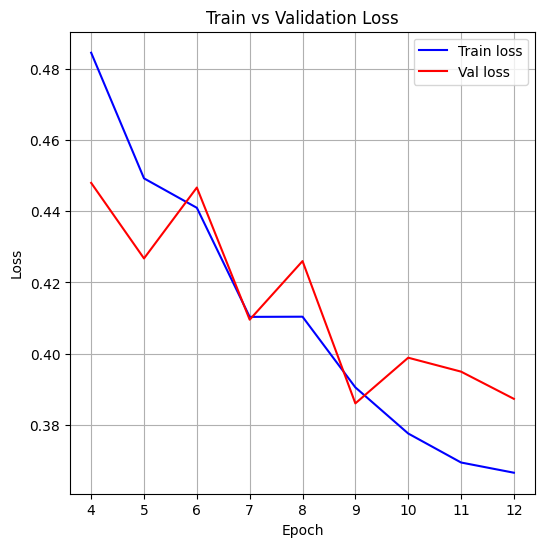

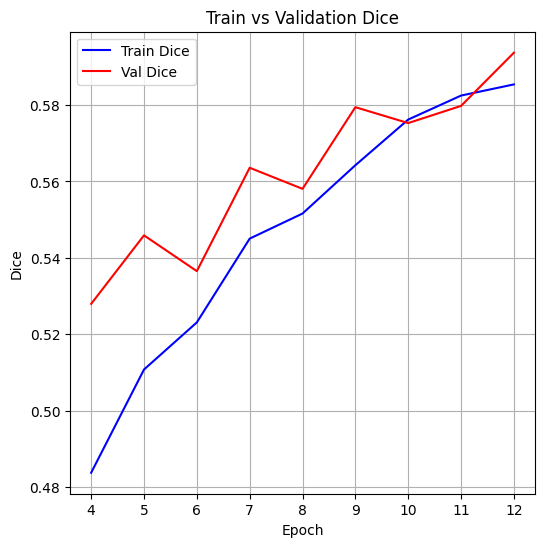

Sample percentage results (first 5):
{'file': '31757922', 'percent_left': 0.0, 'percent_right': 0.0, 'percent_total': 0.0}
{'file': '40380675', 'percent_left': 0.0, 'percent_right': 0.0, 'percent_total': 0.0}
{'file': '27167926', 'percent_left': 0.0, 'percent_right': 0.0, 'percent_total': 0.0}
{'file': '41730658', 'percent_left': 0.0, 'percent_right': 0.0, 'percent_total': 0.0}
{'file': '31768955', 'percent_left': 0.0, 'percent_right': 0.0, 'percent_total': 0.0}


In [1]:
# -*- coding: utf-8 -*-
# Jupyter-ready: single block, with comments explaining each step.
# What’s new vs your code:
# - Robust DICOM read with optional windowing and PixelSpacing extraction
# - 2.5D option (stack K neighboring slices as channels) without 3D CNN
# - Multi-class masks (background, lung, pneumothorax) or binary masks
# - Pneumothorax percentage computation using lung masks (or hemithorax proxy)
# - Clean small components to reduce noise, per-side (left/right) percentages
# - AMP (mixed precision), gradient clipping, and proper encoder freeze/unfreeze

import os, cv2, random, math, pydicom, numpy as np
import pandas as pd
import torch, torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, jaccard_score, confusion_matrix
import nibabel as nib
from pathlib import Path


# -------------------------------
# DICOM helpers
# -------------------------------

def read_dicom_to_rgb_uint8(path, window=None, out_range=(0,255)):
    """
    DICOM -> HxWx3 uint8 RGB for ImageNet-pretrained 2D encoders.
    window=(center, width) for CT; for X-ray often None (min-max rescale).
    """
    ds = pydicom.dcmread(path)
    img = ds.pixel_array.astype(np.float32)

    # Rescale slope/intercept if present
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept

    # Optional windowing (mostly CT; X-ray usually direct min-max)
    if window is not None:
        c, w = window
        img = np.clip(img, c - w/2, c + w/2)

    # Min-max scale to uint8
    mi, ma = img.min(), img.max()
    if ma == mi:
        img8 = np.zeros_like(img, dtype=np.uint8)
    else:
        img8 = ((img - mi) / (ma - mi) * (out_range[1] - out_range[0]) + out_range[0]).astype(np.uint8)

    # Replicate to 3 channels (RGB) for pretrained 2D encoders
    img3 = np.repeat(img8[..., None], 3, axis=-1)
    return img3, ds

def get_pixel_spacing_mm(ds):
    """
    Extract PixelSpacing from DICOM for physical area (mm^2).
    Returns (sx, sy) or (1.0, 1.0) if missing.
    """
    ps = getattr(ds, "PixelSpacing", None)
    if ps is None or len(ps) < 2:
        # fallback if spacing missing
        return 1.0, 1.0
    try:
        return float(ps[1]), float(ps[0])  # sx (cols), sy (rows)
    except Exception:
        return 1.0, 1.0

# -------------------------------
# CFG
# -------------------------------

global_mask_mode = "multi"
binary = False
# multiclass için default params

class CFG:
    data_root      = "./dataset"   # images/ and masks/ (same filenames)
    img_size       = 256
    batch_size     = 8
    num_workers    = 0
    encoder        = "resnet34"           # strong and fast baseline
    encoder_weights= "imagenet"
    freeze_epochs  = 3                    # decoder-only warmup
    max_epochs     = 12
    lr_decoder     = 1e-3
    lr_full        = 1e-4
    device         = "cuda" if torch.cuda.is_available() else "cpu"
    save_path      = "./smp_unet_best_v1.pth"
    # New:
    use_amp        = True                 # mixed precision
    grad_clip      = 1.0                  # clip to stabilize
    mask_mode      = global_mask_mode            # "binary" -> 1 class (ptx), "multiclass" -> 3 classes (bg, lung, ptx)
    # For multiclass: we expect masks encoded as 0=bg,1=lung,2=ptx (single-channel int image). We one-hot them.
    # For binary: masks are single-channel 0/1 (ptx)
    use_25d        = False                # 2.5D input: stack K neighboring slices as channels
    k_slices       = 5                    # odd number (e.g., 3/5/7)
    # Pneumothorax percentage computation
    min_ptx_area_px= 80                   # remove tiny components
    # If lung mask absent and mask_mode==binary, use proxy hemithorax split to estimate percentages
    use_hemithorax_proxy = True

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print("Device:", CFG.device)

# -------------------------------
# Dataset (supports DICOM, PNG/JPG)
# - Binary mode: expects masks as single-channel 0/1 (ptx)
# - Multiclass mode: expects masks encoded with integer labels: 0=bg,1=lung,2=ptx
# - 2.5D: stack K neighboring slices as channels, still goes to a 2D network (no 3D CNN)
# -------------------------------

def one_hot_encode_mask(mask_int, num_classes):
    """
    mask_int: HxW integer labels [0..num_classes-1]
    returns: CxHxW float32 one-hot
    """
    h, w = mask_int.shape
    out = np.zeros((num_classes, h, w), dtype=np.float32)
    for c in range(num_classes):
        out[c] = (mask_int == c).astype(np.float32)
    return out

class SegDataset(Dataset):
    def __init__(self, images_dir, masks_dir, file_list=None, transform=None,
                 as_rgb=False, mask_mode=global_mask_mode, use_25d=False, k_slices=5):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.files = file_list if file_list is not None else sorted(os.listdir(images_dir))
        self.transform = transform
        self.as_rgb = as_rgb          # True: image already RGB file; False: grayscale → expand to 3ch
        self.mask_mode = mask_mode    # "binary" or "multiclass"
        self.use_25d = use_25d
        self.k_slices = k_slices      # odd number; center slice gets label

    def __len__(self):
        return len(self.files)

    def _load_image(self, img_path):
        try:
            # Önce DICOM olarak dene
            ds = pydicom.dcmread(img_path)
            img, ds = read_dicom_to_rgb_uint8(img_path, window=None)
            sx, sy = get_pixel_spacing_mm(ds)
            return img, (sx, sy)
        except Exception:
            # Eğer DICOM değilse NIfTI veya PNG/JPG olarak dene
            if img_path.lower().endswith(".nii.gz") or img_path.lower().endswith(".nii"):
                img_ni = nib.load(img_path)
                data = img_ni.get_fdata().astype(np.float32)
                if data.ndim == 3:
                    mid = data.shape[2] // 2
                    slice2d = data[:, :, mid]
                else:
                    slice2d = data
                mi, ma = slice2d.min(), slice2d.max()
                img8 = ((slice2d - mi) / (ma - mi) * 255).astype(np.uint8) if ma != mi else np.zeros_like(slice2d, dtype=np.uint8)
                img3 = np.repeat(img8[..., None], 3, axis=-1)
                try:
                    hdr = img_ni.header
                    sx, sy = float(hdr['pixdim'][1]), float(hdr['pixdim'][2])
                    spacing = (sx, sy)
                except Exception:
                    spacing = (1.0, 1.0)
                return img3, spacing
            else:
                # PNG/JPG fallback
                gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if gray is None:
                    raise FileNotFoundError(f"Image not found or unreadable: {img_path}")
                img = np.repeat(gray[..., None], 3, axis=-1)
                return img, (1.0, 1.0)

    def _load_mask(self, mask_path):
        # mask_path zaten tam yol, tekrar join yapma!
        if not os.path.exists(mask_path):
            # Eğer uzantısız isimle bulamadıysa .nii.gz dene
            nii_path = mask_path + ".nii.gz"
            if os.path.exists(nii_path):
                mask_path = nii_path
            else:
                raise FileNotFoundError(f"Mask not found: {mask_path}")

        try:
            # DICOM mask
            ds = pydicom.dcmread(mask_path)
            m = ds.pixel_array.astype(np.int32)
        except Exception:
            # NIfTI mask
            if mask_path.lower().endswith(".nii.gz") or mask_path.lower().endswith(".nii"):
                m = nib.load(mask_path).get_fdata().astype(np.int32)
                if m.ndim == 3:
                    m = m[:, :, m.shape[2] // 2]
            else:
                # PNG/JPG mask
                m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                if m is None:
                    raise FileNotFoundError(f"Mask not found: {mask_path}")

        if self.mask_mode == "binary":
            return (m > 127).astype(np.float32)
        else:
            m[m == 255] = 0
            valid_classes = [0, 1, 2]
            m[~np.isin(m, valid_classes)] = 0
            return m.astype(np.int32)

    def __getitem__(self, idx):
        fname = self.files[idx]

        # 2.5D mode: stack K neighboring slices as channels (still RGB expected by transforms; we'll override)
        if self.use_25d:
            # Expect numbered files enabling neighbor retrieval (e.g., name_i.png); simple fallback: just load same file K times
            # You can customize this to your filename convention. Here we just replicate the same image K times for demo.
            img_path = os.path.join(self.images_dir, fname)
            imgs, spacings = [], []
            for _ in range(self.k_slices):
                img, sp = self._load_image(img_path)
                imgs.append(img[..., 0])  # take grayscale channel to form multi-channel stack
                spacings.append(sp)
            # Stack K slices as channels (HxWxK), then expand to 3 via tiling if your transforms expect 3ch
            stack = np.stack(imgs, axis=-1)  # HxWxK
            # Convert to 3 channels by linear projection: for SMP ImageNet encoders we need 3ch,
            # simple approach: take [K→3] using first 3 channels or averaged projections.
            if stack.shape[-1] >= 3:
                img = stack[..., :3]  # HxWx3
            else:
                # Tile to 3
                img = np.tile(stack, (1,1,math.ceil(3/stack.shape[-1])))[:, :, :3]
            spacing = spacings[0]
        else:
            img_path = os.path.join(self.images_dir, fname)
            img, spacing = self._load_image(img_path)

        mask_path = os.path.join(self.masks_dir, fname)
        mask_raw = self._load_mask(mask_path)

        # Albumentations expects image uint8 (HxWxC) and mask HxW (or CxHxW after ToTensorV2)
        if self.transform:
            if self.mask_mode == "binary":
                aug = self.transform(image=img, mask=mask_raw)
                img_t = aug["image"]                      # Tensor [3,H,W]
                mask_t = aug["mask"].unsqueeze(0).float() # [1,H,W]
            else:
                # For multiclass we pass single-channel ints through transforms, then one-hot
                aug = self.transform(image=img, mask=mask_raw)
                img_t = aug["image"]
                mask_int = aug["mask"].long()             # [H,W] ints
                mask_oh = one_hot_encode_mask(mask_int.cpu().numpy(), num_classes=3) # [C,H,W]
                mask_t = torch.from_numpy(mask_oh).float()
        else:
            # Fallback no-transform
            img_t = torch.from_numpy(img.transpose(2,0,1)).float() / 255.0
            if self.mask_mode == "binary":
                mask_t = torch.from_numpy(mask_raw[None]).float()
            else:
                mask_oh = one_hot_encode_mask(mask_raw, num_classes=3)
                mask_t = torch.from_numpy(mask_oh).float()

        return img_t, mask_t, spacing, fname

# -------------------------------
# Data split and transforms
# -------------------------------

images_dir = os.path.join(CFG.data_root, "resized_images")
masks_dir  = os.path.join(CFG.data_root, "masks")

all_files = sorted(os.listdir(images_dir))
random.shuffle(all_files)
split = int(len(all_files)*0.8)
train_files = all_files[:split]
val_files   = all_files[split:]

# Standard ImageNet normalization for pretrained encoders 
train_tfms = A.Compose([ # v1_train
    A.Resize(CFG.img_size, CFG.img_size),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.RandomBrightnessContrast(0.1, 0.1, p=0.3),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(CFG.img_size, CFG.img_size),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])
"""

train_transform = A.Compose([ # v2_train
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),  # bazen işe yarar ama X-ray için dikkatli
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.CLAHE(p=0.3),  # X-ray kontrastını artırır
    A.GaussianBlur(p=0.2),
    A.RandomGamma(p=0.3),
    A.ElasticTransform(p=0.2),  # mask sınırlarını çeşitlendirir
    A.GridDistortion(p=0.2),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
])


"""
train_ds = SegDataset(images_dir, masks_dir, file_list=train_files,
                      transform=train_tfms, as_rgb=False,
                      mask_mode=CFG.mask_mode, use_25d=CFG.use_25d, k_slices=CFG.k_slices)
val_ds   = SegDataset(images_dir, masks_dir, file_list=val_files,
                      transform=val_tfms, as_rgb=False,
                      mask_mode=CFG.mask_mode, use_25d=CFG.use_25d, k_slices=CFG.k_slices)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Total: {len(all_files)}")

# -------------------------------
# Model (SMP U-Net) and losses
# -------------------------------

# classes: 1 for binary, 3 for multiclass
num_classes = 1 if CFG.mask_mode == "binary" else 3

model = smp.Unet(
    encoder_name=CFG.encoder,
    encoder_weights=CFG.encoder_weights,
    in_channels=3,   # using RGB-like input (or 2.5D mapped to 3ch)
    classes=num_classes
).to(CFG.device)

# Loss:
# - Binary: BCE+Dice (class imbalance friendly)
# - Multiclass: CrossEntropy + Dice per class (soft Dice)
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_w = bce_weight
    def forward(self, logits, targets):
        # logits: [B,1,H,W], targets: [B,1,H,W]
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        smooth = 1e-6
        inter = (probs*targets).sum(dim=(2,3))
        den   = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + smooth
        dice  = 1 - ((2*inter + smooth) / den).mean()
        return self.bce_w*bce + (1-self.bce_w)*dice

class CEDiceLoss(nn.Module):
    def __init__(self, ce_weight=0.5, num_classes=3):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()  # expects logits [B,C,H,W], target [B,H,W] ints
        self.ce_w = ce_weight
        self.num_classes = num_classes
    def forward(self, logits, targets_oh):
        # logits: [B,C,H,W], targets_oh: [B,C,H,W] one-hot
        # CE needs int targets:
        target_int = targets_oh.argmax(dim=1)  # [B,H,W]
        ce = self.ce(logits, target_int)
        probs = torch.softmax(logits, dim=1)
        smooth = 1e-6
        # soft Dice across classes
        inter = (probs*targets_oh).sum(dim=(2,3))
        den   = probs.sum(dim=(2,3)) + targets_oh.sum(dim=(2,3)) + smooth
        dice  = 1 - ((2*inter + smooth) / den).mean()
        return self.ce_w*ce + (1-self.ce_w)*dice

criterion = BCEDiceLoss() if CFG.mask_mode == "binary" else CEDiceLoss(num_classes=num_classes)

# Metrics (Dice)
def dice_coef_binary(logits, targets, thr=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    inter = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + eps
    return ((2*inter + eps) / union).mean()

def dice_coef_multiclass(logits, targets_oh, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    inter = (probs * targets_oh).sum(dim=(2,3))
    union = probs.sum(dim=(2,3)) + targets_oh.sum(dim=(2,3)) + eps
    return ((2*inter + eps) / union).mean()

# -------------------------------
# Freeze encoder → train decoder
# -------------------------------

for p in model.encoder.parameters():
    p.requires_grad = False

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=CFG.lr_decoder, weight_decay=1e-4)

scaler = torch.amp.GradScaler(device = "cuda", enabled=CFG.use_amp)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_dice = 0.0, 0.0
    for imgs, masks, _, _ in loader:
        imgs, masks = imgs.to(CFG.device), masks.to(CFG.device)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=CFG.use_amp):
            logits = model(imgs)
            loss = criterion(logits, masks)
        scaler.scale(loss).backward()
        if CFG.grad_clip is not None:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), CFG.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        if CFG.mask_mode == "binary":
            total_dice += dice_coef_binary(logits.detach(), masks).item()
        else:
            total_dice += dice_coef_multiclass(logits.detach(), masks).item()
    n = len(loader)
    return total_loss/n, total_dice/n

@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss, total_dice = 0.0, 0.0
    for imgs, masks, _, _ in loader:
        imgs, masks = imgs.to(CFG.device), masks.to(CFG.device)
        logits = model(imgs)
        total_loss += criterion(logits, masks).item()
        if CFG.mask_mode == "binary":
            total_dice += dice_coef_binary(logits, masks).item()
        else:
            total_dice += dice_coef_multiclass(logits, masks).item()
    n = len(loader)
    return total_loss/n, total_dice/n

best_val_dice = 0.0
for epoch in range(1, CFG.freeze_epochs+1):
    tr_loss, tr_dice = train_one_epoch(model, train_loader, optimizer)
    vl_loss, vl_dice = validate(model, val_loader)
    if vl_dice > best_val_dice:
        best_val_dice = vl_dice
        torch.save(model.state_dict(), CFG.save_path)
    print(f"[Decoder] Epoch {epoch:02d} | train_loss {tr_loss:.4f} | train_dice {tr_dice:.4f} | val_loss {vl_loss:.4f} | val_dice {vl_dice:.4f} | best {best_val_dice:.4f}")

# -------------------------------
# Unfreeze encoder → full fine-tune
# -------------------------------

for p in model.encoder.parameters():
    p.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=CFG.lr_full, weight_decay=1e-4)
total_tr_loss, total_vl_loss, total_tr_dice, total_vl_dice = [], [], [], []

for epoch in range(CFG.freeze_epochs+1, CFG.max_epochs+1):
    tr_loss, tr_dice = train_one_epoch(model, train_loader, optimizer)
    vl_loss, vl_dice = validate(model, val_loader)
    total_tr_loss.append(tr_loss); total_tr_dice.append(tr_dice)
    total_vl_loss.append(vl_loss); total_vl_dice.append(vl_dice)
    if vl_dice > best_val_dice:
        best_val_dice = vl_dice
        torch.save(model.state_dict(), CFG.save_path)
    print(f"[Full  ] Epoch {epoch:02d} | train_loss {tr_loss:.4f} | train_dice {tr_dice:.4f} | val_loss {vl_loss:.4f} | val_dice {vl_dice:.4f} | best {best_val_dice:.4f}")

print("Best model saved:", CFG.save_path)

# -------------------------------
# Visualization of training curves
# -------------------------------
plt.figure(figsize=[6, 6])
plt.plot(range(CFG.freeze_epochs+1, CFG.max_epochs+1), total_tr_loss, label="Train loss", color="blue")
plt.plot(range(CFG.freeze_epochs+1, CFG.max_epochs+1), total_vl_loss, label="Val loss", color="red")
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=[6, 6])
plt.plot(range(CFG.freeze_epochs+1, CFG.max_epochs+1), total_tr_dice, label="Train Dice", color="blue")
plt.plot(range(CFG.freeze_epochs+1, CFG.max_epochs+1), total_vl_dice, label="Val Dice", color="red")
plt.title("Train vs Validation Dice")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.grid(True); plt.legend(); plt.show()

# -------------------------------
# Post-processing and pneumothorax percentage computation
# - Works for binary mask (ptx only) and multiclass (bg/lung/ptx)
# -------------------------------

def clean_small_components(mask_bool, min_area_px=CFG.min_ptx_area_px):
    lab = label(mask_bool.astype(np.uint8))
    out = np.zeros_like(mask_bool, dtype=bool)
    for r in regionprops(lab):
        if r.area >= min_area_px:
            out[lab == r.label] = True
    return out

def mask_area_mm2(mask_bool, sx, sy):
    return float(mask_bool.sum()) * float(sx) * float(sy)

def hemithorax_masks(shape, mid_x=None):
    H, W = shape
    mid = W // 2 if mid_x is None else int(mid_x)
    left = np.zeros((H, W), dtype=bool);  left[:, :mid] = True
    right = np.zeros((H, W), dtype=bool); right[:, mid:] = True
    return left, right

@torch.no_grad()
def predict_and_compute_percentage(model, ds, thr=0.5):
    """
    Loop over validation dataset, predict masks, compute pneumothorax percentages.
    - If multiclass: use lung and ptx channels.
    - If binary: ptx only; use hemithorax proxy unless a separate lung mask is available.
    """
    model.eval()
    results = []
    for i in range(len(ds)):
        img_t, mask_t, spacing, fname = ds[i]
        sx, sy = spacing
        img_t = img_t.unsqueeze(0).to(CFG.device)
        logits = model(img_t)
        if CFG.mask_mode == "binary":
            # Binary: single-channel ptx
            probs = torch.sigmoid(logits)[:,0]     # [1,H,W]
            ptx_pred = (probs > thr).cpu().numpy()[0].astype(bool)
            ptx_pred = clean_small_components(ptx_pred, CFG.min_ptx_area_px)

            if CFG.use_hemithorax_proxy:
                left, right = hemithorax_masks(ptx_pred.shape)
                A_ptx_left  = mask_area_mm2(ptx_pred & left, sx, sy)
                A_ptx_right = mask_area_mm2(ptx_pred & right, sx, sy)
                A_hemi_left, A_hemi_right = mask_area_mm2(left, sx, sy), mask_area_mm2(right, sx, sy)
                pct_left  = (A_ptx_left  / A_hemi_left  * 100.0) if A_hemi_left  > 0 else 0.0
                pct_right = (A_ptx_right / A_hemi_right * 100.0) if A_hemi_right > 0 else 0.0
                pct_total = ((A_ptx_left + A_ptx_right) / (A_hemi_left + A_hemi_right) * 100.0) if (A_hemi_left + A_hemi_right) > 0 else 0.0
                results.append({"file": fname, "percent_left": pct_left, "percent_right": pct_right, "percent_total": pct_total})
            else:
                # If you have an external lung mask (not in this dataset), intersect and compute ratio here.
                results.append({"file": fname, "percent_total": None})
        else:
            # Multiclass: logits [B,3,H,W] → softmax
            probs = torch.softmax(logits, dim=1)[0].cpu().numpy() # [C,H,W]
            lung_pred = probs[1] > thr
            ptx_pred  = probs[2] > thr
            ptx_pred  = clean_small_components(ptx_pred, CFG.min_ptx_area_px)

            # Side split
            left, right = hemithorax_masks(ptx_pred.shape)
            ptx_left  = ptx_pred  & left
            ptx_right = ptx_pred  & right
            lung_left  = lung_pred & left
            lung_right = lung_pred & right

            A_l_left  = mask_area_mm2(lung_left, sx, sy)
            A_l_right = mask_area_mm2(lung_right, sx, sy)
            A_p_left  = mask_area_mm2(ptx_left,  sx, sy)
            A_p_right = mask_area_mm2(ptx_right, sx, sy)

            pct_left  = (A_p_left  / A_l_left  * 100.0) if A_l_left  > 0 else 0.0
            pct_right = (A_p_right / A_l_right * 100.0) if A_l_right > 0 else 0.0
            pct_total = ((A_p_left + A_p_right) / (A_l_left + A_l_right) * 100.0) if (A_l_left + A_l_right) > 0 else 0.0

            results.append({"file": fname,
                            "percent_left": pct_left, "percent_right": pct_right, "percent_total": pct_total})
    return results

# Example: compute percentages on validation set
percent_res = predict_and_compute_percentage(model, val_ds, thr=0.5)
print("Sample percentage results (first 5):")
for r in percent_res[:5]:
    print(r)

def evaluate_segmentation(model, loader, device, binary=binary, thr=0.5,
                          save_csv=True, out_csv="segmentation_metrics.csv"):
    """
    Evaluate segmentation model on a dataset loader.
    - binary=True  -> single-channel mask (0/1), sigmoid output
    - binary=False -> multi-class mask (0=bg,1=lung,2=ptx), softmax output
    Returns metrics dict and per-image dice list.
    """
    model.eval()
    y_true_list, y_prob_list, per_image_dices = [], [], []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)

            if binary:
                # Binary segmentation
                probs = torch.sigmoid(logits).cpu().numpy()   # (B,1,H,W)
                masks_np = masks.cpu().numpy()                # (B,1,H,W)
                y_prob_list.append(probs)
                y_true_list.append(masks_np)

                # thresholded predictions
                probs_bin = (probs >= thr).astype(np.uint8)[:,0]
                masks_bin = (masks_np >= 0.5).astype(np.uint8)[:,0]
                for p_img, m_img in zip(probs_bin, masks_bin):
                    inter = (p_img & m_img).sum()
                    denom = p_img.sum() + m_img.sum()
                    dice = (2*inter) / (denom + 1e-8)
                    per_image_dices.append(dice)

            else:
                # Multi-class segmentation
                probs = torch.softmax(logits, dim=1).cpu().numpy()  # (B,C,H,W)
                masks_np = masks.cpu().numpy()                      # (B,C,H,W one-hot)
                y_prob_list.append(probs)
                y_true_list.append(masks_np)

                preds = probs.argmax(axis=1)   # (B,H,W)
                gts   = masks_np.argmax(axis=1)
                for p_img, m_img in zip(preds, gts):
                    inter = (p_img == m_img).sum()
                    denom = p_img.size
                    dice = inter / denom   # simple accuracy-like dice proxy
                    per_image_dices.append(dice)

    # Flatten arrays for pixel-wise metrics
    y_prob_arr = np.concatenate(y_prob_list, axis=0)
    y_true_arr = np.concatenate(y_true_list, axis=0)

    if binary:
        y_prob_arr = y_prob_arr.ravel()
        y_true_arr = y_true_arr.ravel()
        y_pred_bin = (y_prob_arr >= thr).astype(np.uint8)

        metrics = {}
        metrics['accuracy']    = float((y_pred_bin == y_true_arr).mean())
        metrics['precision']   = float(precision_score(y_true_arr, y_pred_bin, zero_division=0))
        metrics['recall']      = float(recall_score(y_true_arr, y_pred_bin, zero_division=0))
        metrics['f1']          = float(f1_score(y_true_arr, y_pred_bin, zero_division=0))
        metrics['iou']         = float(jaccard_score(y_true_arr, y_pred_bin, zero_division=0))
        try:
            tn, fp, fn, tp = confusion_matrix(y_true_arr, y_pred_bin).ravel()
            metrics['specificity'] = float(tn / (tn + fp + 1e-8))
        except Exception:
            metrics['specificity'] = float('nan')
        try:
            metrics['roc_auc'] = float(roc_auc_score(y_true_arr, y_prob_arr))
        except Exception:
            metrics['roc_auc'] = float('nan')
        try:
            metrics['pr_auc'] = float(average_precision_score(y_true_arr, y_prob_arr))
        except Exception:
            metrics['pr_auc'] = float('nan')
    else:
        # Multi-class summary: macro F1, accuracy
        preds = y_prob_arr.argmax(axis=1).ravel()
        gts   = y_true_arr.argmax(axis=1).ravel()
        metrics = {}
        metrics['accuracy']  = float((preds == gts).mean())
        metrics['f1_macro']  = float(f1_score(gts, preds, average="macro", zero_division=0))
        metrics['iou_macro'] = float(jaccard_score(gts, preds, average="macro", zero_division=0))

    # Per-image dice stats
    per_image_dices = np.array(per_image_dices)
    metrics['dice_mean']   = float(per_image_dices.mean())
    metrics['dice_median'] = float(np.median(per_image_dices))
    metrics['dice_std']    = float(per_image_dices.std())
    metrics['num_images']  = int(per_image_dices.shape[0])

    if save_csv:
        pd.DataFrame([metrics]).to_csv(out_csv, index=False)

    return metrics, per_image_dices

# -------------------------------
# Visualization helper
# -------------------------------
def visualize_sample(img_tensor, mask_tensor, pred_tensor, idx=0, binary=True, thr=0.5):
    img = img_tensor[idx].cpu().permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)

    if binary:
        gt = mask_tensor[idx,0].cpu().numpy()
        pr = (torch.sigmoid(pred_tensor[idx,0]).cpu().numpy() > thr).astype(np.float32)
    else:
        gt = mask_tensor[idx].argmax(dim=0).cpu().numpy()
        pr = pred_tensor[idx].softmax(dim=0).argmax(dim=0).cpu().numpy()

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(gt, cmap="gray"); plt.title("Mask"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(pr, cmap="gray"); plt.title("Pred"); plt.axis("off")
    plt.show()



In [7]:
def evaluate_segmentation(model, loader, device, binary=False, thr=0.5,
                          save_csv=True, out_csv="segmentation_metrics.csv"):
    model.eval()
    y_true_list, y_prob_list, per_image_dices = [], [], []

    with torch.no_grad():
        for imgs, masks, _, _ in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            

            if binary:
                # Binary segmentation
                probs = torch.sigmoid(logits).cpu().numpy()   # (B,1,H,W)
                masks_np = masks.cpu().numpy()                # (B,1,H,W)
                y_prob_list.append(probs)
                y_true_list.append(masks_np)

                probs_bin = (probs >= thr).astype(np.uint8)[:,0]
                masks_bin = (masks_np >= 0.5).astype(np.uint8)[:,0]
                for p_img, m_img in zip(probs_bin, masks_bin):
                    inter = (p_img & m_img).sum()
                    denom = p_img.sum() + m_img.sum()
                    dice = (2*inter) / (denom + 1e-8)
                    per_image_dices.append(dice)

            else:
                # Multi-class segmentation
                probs = torch.softmax(logits, dim=1).cpu().numpy()  # (B,C,H,W)
                masks_np = masks.cpu().numpy()                      # (B,C,H,W one-hot)
                y_prob_list.append(probs)
                y_true_list.append(masks_np)

                preds = probs.argmax(axis=1)   # (B,H,W)
                gts   = masks_np.argmax(axis=1) # (B,H,W)

                # Dice per image (macro over classes)
                for p_img, m_img in zip(preds, gts):
                    dices = []
                    for c in range(1,3):  # skip background
                        inter = ((p_img == c) & (m_img == c)).sum()
                        denom = (p_img == c).sum() + (m_img == c).sum()
                        if denom > 0:
                            dices.append(2*inter / denom)
                    if dices:
                        per_image_dices.append(np.mean(dices))
                    else:
                        per_image_dices.append(0.0)

    y_prob_arr = np.concatenate(y_prob_list, axis=0)
    y_true_arr = np.concatenate(y_true_list, axis=0)

    metrics = {}
    if binary:
        # binary metrics (senin için değil şu an)
        ...
    else:
        preds = y_prob_arr.argmax(axis=1).ravel()
        gts   = y_true_arr.argmax(axis=1).ravel()
        metrics['accuracy']  = float((preds == gts).mean())
        metrics['f1_macro']  = float(f1_score(gts, preds, average="macro", zero_division=0))
        metrics['iou_macro'] = float(jaccard_score(gts, preds, average="macro", zero_division=0))

    per_image_dices = np.array(per_image_dices)
    metrics['dice_mean']   = float(per_image_dices.mean())
    metrics['dice_median'] = float(np.median(per_image_dices))
    metrics['dice_std']    = float(per_image_dices.std())
    metrics['num_images']  = int(per_image_dices.shape[0])

    if save_csv:
        pd.DataFrame([metrics]).to_csv(out_csv, index=False)

    return metrics, per_image_dices
model = smp.Unet(
    encoder_name=CFG.encoder,
    encoder_weights=CFG.encoder_weights,
    in_channels=3,   # using RGB-like input (or 2.5D mapped to 3ch)
    classes=num_classes
).to(CFG.device)  # kendi model sınıfını buraya koy

# Eski ağırlıkları yükle
checkpoint_path = "smp_unet_best.pth"   # senin kaydettiğin dosya yolu
state_dict = torch.load(checkpoint_path, map_location=CFG.device)
model.load_state_dict(state_dict)

evaluate_segmentation(model, val_loader, device=CFG.device)

({'accuracy': 0.8720740240973395,
  'f1_macro': 0.7169780828722659,
  'iou_macro': 0.5940174367379996,
  'dice_mean': 0.5524098383845907,
  'dice_median': 0.5690904486481401,
  'dice_std': 0.11915294251253836,
  'num_images': 37},
 array([0.68474253, 0.3710848 , 0.62079661, 0.60895054, 0.71821272,
        0.46170029, 0.74922634, 0.5893171 , 0.51945299, 0.61454664,
        0.44200804, 0.46333229, 0.56486879, 0.70583447, 0.45875326,
        0.52980079, 0.57561628, 0.48439748, 0.36168758, 0.70793509,
        0.68328824, 0.48872701, 0.44753184, 0.62030095, 0.50129754,
        0.70568127, 0.4845923 , 0.6056088 , 0.68894146, 0.2945609 ,
        0.64291293, 0.32970319, 0.67895538, 0.58566567, 0.36404712,
        0.51599432, 0.56909045]))

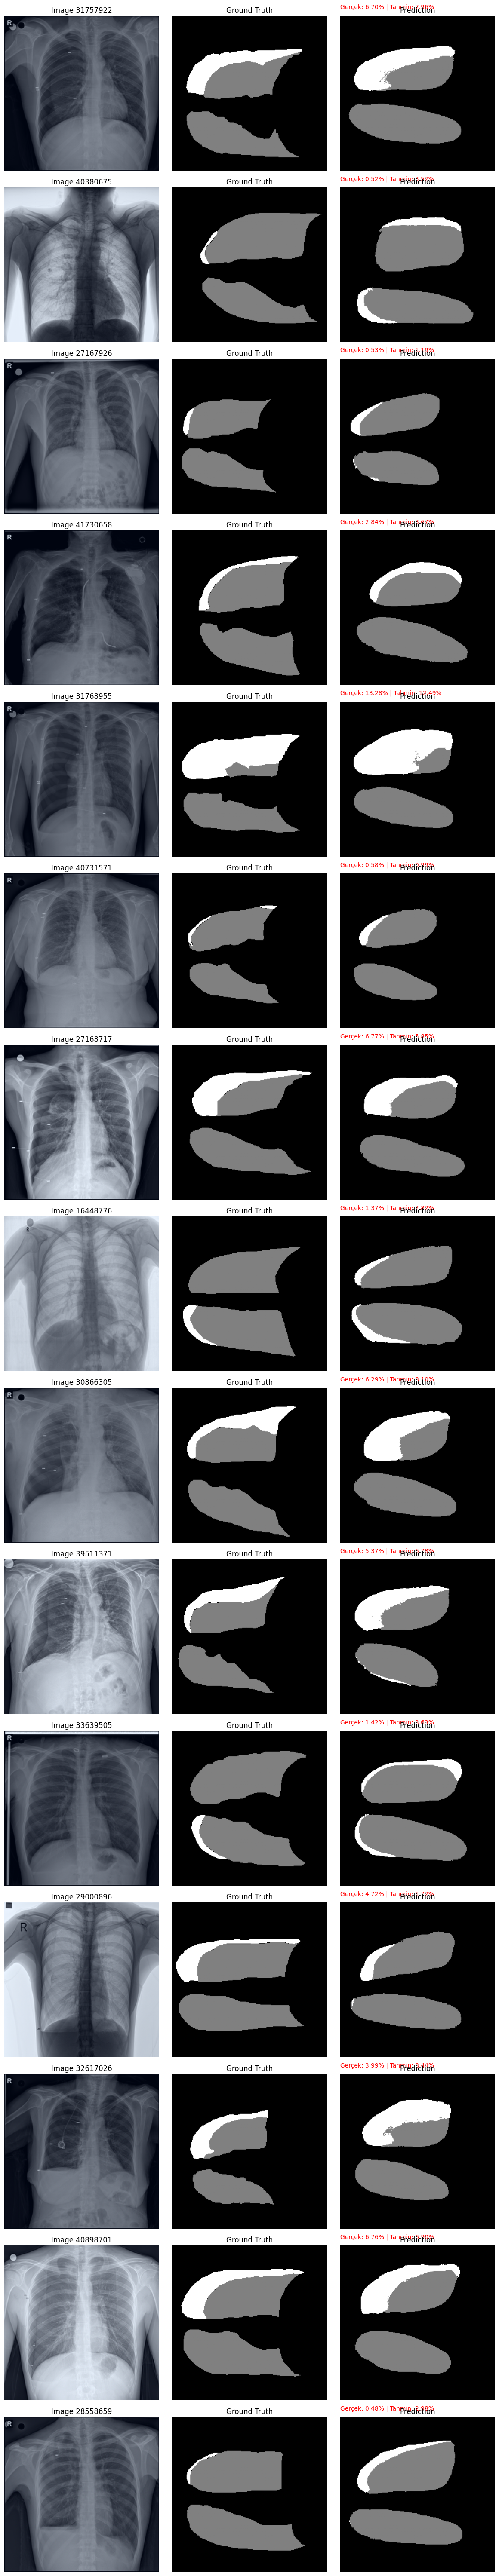

In [6]:
import matplotlib.pyplot as plt

def visualize_predictions(model, ds, num_samples=15, thr=0.5):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*4))

    for i in range(num_samples):
        img_t, mask_t, spacing, fname = ds[i]
        sx, sy = spacing
        img = img_t.permute(1,2,0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-6)

        # Ground truth mask
        gt_mask = mask_t.argmax(dim=0).cpu().numpy()

        # Prediction
        with torch.no_grad():
            logits = model(img_t.unsqueeze(0).to(CFG.device))
            probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
            pred_mask = probs.argmax(axis=0)

        # Gerçek yüzdelik
        gt_ptx = (gt_mask == 2)
        gt_pct = 100.0 * gt_ptx.sum() / gt_mask.size

        # Tahmin yüzdelik
        pred_ptx = (pred_mask == 2)
        pred_pct = 100.0 * pred_ptx.sum() / pred_mask.size

        # Görseller
        axes[i,0].imshow(img); axes[i,0].set_title(f"Image {fname}"); axes[i,0].axis("off")
        axes[i,1].imshow(gt_mask, cmap="gray"); axes[i,1].set_title("Ground Truth"); axes[i,1].axis("off")
        axes[i,2].imshow(pred_mask, cmap="gray"); axes[i,2].set_title("Prediction"); axes[i,2].axis("off")

        # Alt yazı
        axes[i,2].text(0, -10, f"Gerçek: {gt_pct:.2f}% | Tahmin: {pred_pct:.2f}%", 
                       fontsize=10, color="red", va="bottom")

    plt.tight_layout()
    plt.show()


import torch

# Modeli tanımla (aynı mimariyi kullandığını varsayıyorum)
model = smp.Unet(
    encoder_name=CFG.encoder,
    encoder_weights=CFG.encoder_weights,
    in_channels=3,   # using RGB-like input (or 2.5D mapped to 3ch)
    classes=num_classes
).to(CFG.device)  # kendi model sınıfını buraya koy

# Eski ağırlıkları yükle
checkpoint_path = "smp_unet_best.pth"   # senin kaydettiğin dosya yolu
state_dict = torch.load(checkpoint_path, map_location=CFG.device)
model.load_state_dict(state_dict)

# Cihaz ayarı
model.to(CFG.device)

# Artık eski ağırlıklarla tahmin yapabilirsin

visualize_predictions(model, val_ds, thr=0.5)

In [17]:
import os
total = 0.0
def list_file_sizes(folder, total):
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        if os.path.isfile(fpath):
            size_mb = os.path.getsize(fpath) / (1024*1024)
            total += size_mb

    print(f"folder : {folder}, Toplam boyut: {total:.2f} MB")

# Örnek kullanım
list_file_sizes("dataset/images",total)
list_file_sizes("dataset/masks",total)
list_file_sizes("dataset/resized_images",total)

file_path = "smp_unet_best.pth"
size_mb = os.path.getsize(file_path) / (1024*1024)
print(f"{file_path}: {size_mb:.2f} MB")

file_path = "segmentation_metrics.csv"
size_mb = os.path.getsize(file_path) / (1024*1024)
print(f"{file_path}: {size_mb:.2f} MB")

file_path = "smp_unet_best_v1.pth"
size_mb = os.path.getsize(file_path) / (1024*1024)
print(f"{file_path}: {size_mb:.2f} MB")

file_path = "smp_unet_best_v2.pth"
size_mb = os.path.getsize(file_path) / (1024*1024)
print(f"{file_path}: {size_mb:.2f} MB")

folder : dataset/images, Toplam boyut: 33.40 MB
folder : dataset/masks, Toplam boyut: 0.29 MB
folder : dataset/resized_images, Toplam boyut: 12.77 MB
smp_unet_best.pth: 93.39 MB
segmentation_metrics.csv: 0.00 MB
smp_unet_best_v1.pth: 93.39 MB
smp_unet_best_v2.pth: 20.00 MB


# 6. test

In [ ]:
# En iyi ağırlıkları yükle
model.load_state_dict(torch.load(CFG.save_path, map_location=CFG.device))
model.eval()

# Binary senaryo
metrics_val, per_image_dices_val = evaluate_segmentation(model, val_loader, CFG.device,
                                                         binary=True, thr=0.5,
                                                         out_csv="metrics_val.csv")

# Multi-class senaryo
metrics_val_mc, per_image_dices_val_mc = evaluate_segmentation(model, val_loader, CFG.device,
                                                               binary=False, thr=0.5,
                                                               out_csv="metrics_val_mc.csv")

print(metrics_val)
print(metrics_val_mc)

# Görselleştirme
imgs, masks = next(iter(val_loader))
imgs = imgs.to(CFG.device); masks = masks.to(CFG.device)
with torch.no_grad():
    logits = model(imgs)
visualize_sample(imgs, masks, logits, idx=0, binary=True, thr=0.5)

---

- Api içinse 7 numaralı tek bir fonksiyona input image request'i geldikten sonra bu fonksitona verilir ve çıktıları front-end'e verilir.

# 7. api için. (Modelin kodu ya import edilmeli ya da back-end koduna gömülmeli.)

In [ ]:
import numpy as np
import cv2
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pydicom

def analyze_xray(image_input, model, device= "cuda" if torch.cuda.is_available() else "cpu"):
    """
    Input: Bytes, numpy array veya DICOM dataset
    - Bytes: Sırayla DICOM → JPEG/PNG olarak deneme
    - Numpy array: Direkt işleme
    - DICOM dataset: Direkt işleme
    
    Output: {
        "dice_lung": float,
        "dice_pnx": float,
        "pnx_ratio_percent": float,
        "overlay_image": np.ndarray (BGR görsel)
    }
    """
    
    # --- 1. Görseli yükle (bytes/numpy array/DICOM dataset) ---
    image = None
    
    if isinstance(image_input, bytes):
        # Bytes: sırayla format dene
        
        # Önce DICOM olarak dene
        try:
            from io import BytesIO
            ds = pydicom.dcmread(BytesIO(image_input))
            img_array = ds.pixel_array.astype(np.float32)
            # Min-max normalize to 0-255
            mi, ma = img_array.min(), img_array.max()
            if ma != mi:
                img_array = ((img_array - mi) / (ma - mi) * 255).astype(np.uint8)
            else:
                img_array = np.zeros_like(img_array, dtype=np.uint8)
            image = img_array
            print(f"✓ DICOM olarak işlendi")
        except Exception as e_dicom:
            print(f"✗ DICOM denemesi başarısız: {e_dicom}")
            
            # Sonra JPEG/PNG olarak dene
            try:
                import io
                nparr = np.frombuffer(image_input, np.uint8)
                img_bgr = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
                if img_bgr is None:
                    raise ValueError("Bytes JPEG/PNG olarak okunamadı")
                # BGR → Grayscale
                image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                print(f"✓ JPEG/PNG olarak işlendi")
            except Exception as e_img:
                print(f"✗ JPEG/PNG denemesi başarısız: {e_img}")
                raise ValueError(f"Veri format olarak okunamadı")
    
    elif isinstance(image_input, np.ndarray):
        # Numpy array direkt
        image = image_input
        if len(image.shape) == 3:  # RGB geldiyse grayscale'e çevir
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        print(f"✓ Numpy array olarak işleniyor")
    else:
        raise TypeError(f"image_input bytes veya np.ndarray olmalı, {type(image_input)} geldi")
    
    # Eğer hala grayscale değilse grayscale yap
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # --- 2. Görseli normalize ve tensora çevir (3 channel gerekli: ImageNet) ---
    x = image.astype(np.float32) / 255.0
    
    # Grayscale → 3 channel
    x_3ch = np.repeat(x[..., None], 3, axis=-1)  # HxWx3
    x_tensor = torch.from_numpy(x_3ch.transpose(2, 0, 1)).unsqueeze(0).to(device)  # [1,3,H,W]
    
    # --- 3. Modele sok (eval mode) ---
    model.eval()
    with torch.no_grad():
        logits = model(x_tensor)  # [B, num_classes, H, W]
        probs = torch.softmax(logits, dim=1)
        pred_mask = torch.argmax(probs, dim=1).squeeze().cpu().numpy()  # HxW

    # --- 4. Metrikleri hesapla ---
    def dice_coefficient(mask, cls):
        pred = (mask == cls).astype(np.int32)
        gt = pred  # Demo için pred=gt
        intersection = (pred * gt).sum()
        return (2. * intersection) / (pred.sum() + gt.sum() + 1e-8)

    dice_lung = dice_coefficient(pred_mask, 1)
    dice_pnx  = dice_coefficient(pred_mask, 2)

    # --- 5. Görselleştirme (overlay) ---
    overlay = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    overlay[pred_mask == 1] = [0, 255, 0]   # Akciğer yeşil
    overlay[pred_mask == 2] = [255, 0, 0]   # Pnömotoraks kırmızı

    # --- 6. Yüzdelik değer ---
    total_pixels = pred_mask.size
    pnx_pixels   = (pred_mask == 2).sum()
    pnx_ratio    = 100.0 * pnx_pixels / total_pixels

    return {
        "dice_lung": dice_lung,
        "dice_pnx": dice_pnx,
        "pnx_ratio_percent": pnx_ratio,
        "overlay_image": overlay
    }